# 01 Replication of the head-FT result (Furui and Ohue, arXiv:2609.24302)

Self-filling over the 8 targets: every target whose No-FT and 15 head-FT arms (3 budgets x 5 seeds) are fully scored is analysed; the rest print a pending line and appear as paper-only placeholders. Metrics (AP, EF@1%, BEDROC alpha=20) are computed here from the per-compound scores with the authors' `BoltzFT/evaluation/metrics.py`. Cross-target statistics use targets as the analysis unit, on per-target values averaged over the 5 seeds.

In [1]:

import sys; sys.path.insert(0, "/global/scratch/users/sergiomar10/boltzaff/pipeline_local")
from bft_replication import *
import matplotlib.pyplot as plt
from IPython.display import display
style()
MT = {}
for t in TARGETS:
    try: d = metrics_table(t)
    except Exception as e: d = None; print(f"{SHORT[t]}: error while computing metrics: {e!r}")
    if d is None: print(f"pending: {SHORT[t]} - needs No-FT and all 15 head-FT arms scored (status {status().loc[SHORT[t], 'arms_scored']})")
    else: MT[t] = d
DONE = list(MT); K = len(DONE)
print("\n" + "=" * 50 + f"\n  n targets = {K} (of 8): {[SHORT[t] for t in DONE]}\n" + "=" * 50)
if K < 2: print("k < 2: cross-target tests (sign test, Wilcoxon, t-CI) cannot be computed yet; only per-target values are shown.")
elif K < 6: print(f"k = {K}: the two-sided sign test cannot reach p < 0.05 with fewer than 6 targets (minimum p = {2*0.5**K:.3f}); treat all cross-target p-values as descriptive.")
BUD = BUDGETS
def ours_base(t, m): d = MT[t]; return float(d[d.arm == "base"][m].iloc[0])
def ours_seeds(t, N, m): d = MT[t]; return d[(d.arm == "headft") & (d.n_train == N)][m].values
def paper_base(t, m): return float(PAPER_BASE.loc[t, MCOLS[m]])
def paper_ft(t, N, m): return float(PAPER_FT.loc[(t, N), MCOLS[m]])


pending: 485317 - needs No-FT and all 15 head-FT arms scored (status 0/16)


pending: 2097 - needs No-FT and all 15 head-FT arms scored (status 0/16)


pending: 493091 - needs No-FT and all 15 head-FT arms scored (status 0/16)


pending: 2650 - needs No-FT and all 15 head-FT arms scored (status 0/16)


pending: 588549 - needs No-FT and all 15 head-FT arms scored (status 0/16)

  n targets = 3 (of 8): ['588689', '504329', '743445']
k = 3: the two-sided sign test cannot reach p < 0.05 with fewer than 6 targets (minimum p = 0.250); treat all cross-target p-values as descriptive.


## 1. The paper's own numbers (all 8 targets, reference)
Geometric mean over the 8 targets of head-FT / No-FT, computed from the released per-target values (trainer_control.csv). The paper states AP 2.14x and EF@1% 1.77x at N=300.

In [2]:
rows = []
for m in MCOLS:
    for N in BUD:
        g = geo_stats([paper_ft(t, N, m) / paper_base(t, m) for t in TARGETS])
        rows.append({"metric": MNAME[m], "N": N, "paper_geo_mean_ratio": g["geo"], "95% t-CI": f"[{g['lo']:.2f}, {g['hi']:.2f}]", "improved": f"{g['improved']}/8", "sign_p": g["sign_p"], "wilcoxon_p": g["wilcoxon_p"]})
PAPER_T2 = pd.DataFrame(rows); display(PAPER_T2.style.format(precision=3))
PG = {(r.metric, r.N): r.paper_geo_mean_ratio for r in PAPER_T2.itertuples()}
print(f"paper reference at N=300 (8 targets): AP {PG[('AP',300)]:.2f}x, EF@1% {PG[('EF@1%',300)]:.2f}x, BEDROC {PG[('BEDROC(a=20)',300)]:.2f}x")

,metric,N,paper_geo_mean_ratio,95% t-CI,improved,sign_p,wilcoxon_p
0,AP,40,1.239,"[0.87, 1.75]",6/8,0.289,0.148
1,AP,100,1.556,"[1.18, 2.04]",8/8,0.008,0.008
2,AP,300,2.137,"[1.44, 3.17]",8/8,0.008,0.008
3,EF@1%,40,1.241,"[0.77, 2.01]",6/8,0.289,0.312
4,EF@1%,100,1.588,"[1.13, 2.23]",7/8,0.070,0.018
5,EF@1%,300,1.766,"[1.28, 2.44]",8/8,0.008,0.008
6,BEDROC(a=20),40,1.021,"[0.86, 1.21]",5/8,0.727,0.844
7,BEDROC(a=20),100,1.142,"[1.02, 1.27]",7/8,0.070,0.039
8,BEDROC(a=20),300,1.211,"[1.04, 1.41]",7/8,0.070,0.023


paper reference at N=300 (8 targets): AP 2.14x, EF@1% 1.77x, BEDROC 1.21x


## 1b. The No-FT starting point for all 8 targets (available now)
Three No-FT numbers per target: the **paper's** reported value; the **dataset's shipped Boltz-2 probability** scored on the paper's own eval subset (`selection/eval_subset.csv`, available for every target now, so this checks the labels, the eval-set definition and our metric code on all 8 targets); and **our own No-FT re-scoring** through the two-pass pipeline, which appears for a target as soon as its No-FT arm is fully scored (it does not wait for the head-FT arms). The shipped score is the paper group's own run, so agreement with the paper checks the evaluation, not our Boltz-2 runs; the third column is the real test of our pipeline.

,paper_n_eval,shipped_n_eval,paper_n_active,shipped_n_active,paper_AP,shipped_AP,ours_AP,paper_EF1,shipped_EF1,ours_EF1,spearman_ours_vs_shipped
target,,,,,,,,,,,
588689,49685,49685,396,396,0.096,0.095,0.097,18.176,18.429,16.914,0.943
504329,49682,49682,438,438,0.047,0.049,0.051,7.988,9.814,9.812,0.892
743445,49695,49695,134,134,0.022,0.021,0.022,15.670,14.924,16.416,0.986
485317,49680,49680,953,953,0.036,0.035,NaN,3.461,3.461,NaN,NaN
2097,49615,49615,415,415,0.081,0.076,NaN,18.078,16.390,NaN,NaN
493091,49685,49685,739,739,0.059,0.057,NaN,7.170,6.899,NaN,NaN
2650,49582,49582,542,542,0.071,0.072,NaN,13.833,12.173,NaN,NaN
588549,49687,49687,150,150,0.006,0.007,NaN,2.666,3.999,NaN,NaN


eval-set size and active count identical to the paper for 8 of 8 targets
|shipped AP - paper AP|: median 0.0012, max 0.0050 (2097)
our No-FT, target 588689: AP 0.097 vs paper 0.096 (shipped 0.095); Spearman with the shipped score 0.943
our No-FT, target 504329: AP 0.051 vs paper 0.047 (shipped 0.049); Spearman with the shipped score 0.892
our No-FT, target 743445: AP 0.022 vs paper 0.022 (shipped 0.021); Spearman with the shipped score 0.986


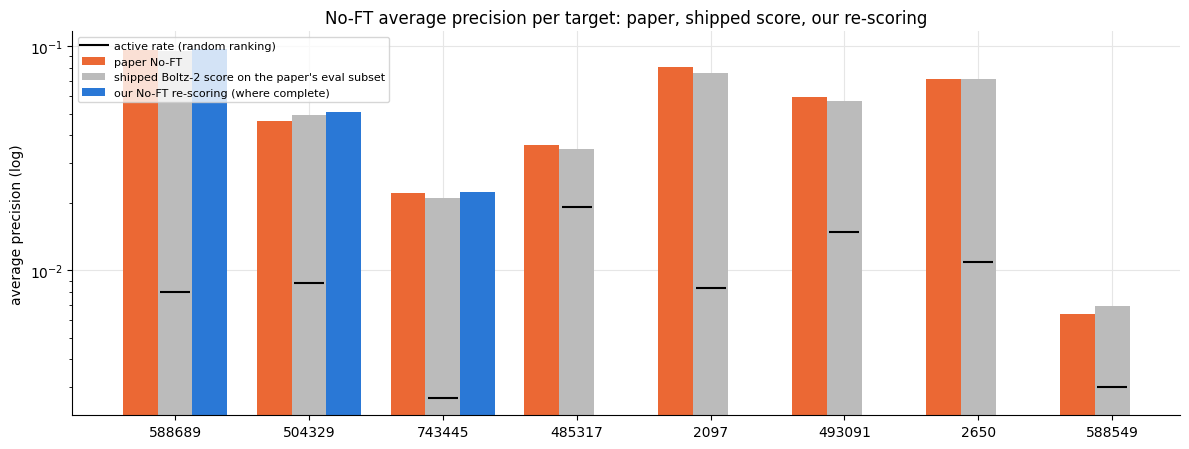

In [3]:
NT = nofT_table()
cols = ["paper_n_eval","shipped_n_eval","paper_n_active","shipped_n_active","paper_AP","shipped_AP","ours_AP","paper_EF1","shipped_EF1","ours_EF1","spearman_ours_vs_shipped"]
display(NT[[c for c in cols if c in NT]].round(3))
same = ((NT.paper_n_eval == NT.shipped_n_eval) & (NT.paper_n_active == NT.shipped_n_active)).sum()
print(f"eval-set size and active count identical to the paper for {same} of {len(NT)} targets")
dap = (NT.shipped_AP - NT.paper_AP).abs(); print(f"|shipped AP - paper AP|: median {dap.median():.4f}, max {dap.max():.4f} ({NT.index[dap.argmax()]})")
if NT.ours_AP.notna().any():
    o = NT[NT.ours_AP.notna()]
    for tg, r in o.iterrows(): print(f"our No-FT, target {tg}: AP {r.ours_AP:.3f} vs paper {r.paper_AP:.3f} (shipped {r.shipped_AP:.3f}); Spearman with the shipped score {r.spearman_ours_vs_shipped:.3f}")
else: print("pending: our own No-FT re-scoring is not complete for any target yet")
fig, ax = plt.subplots(figsize=(12, 4.6)); x = np.arange(len(NT)); w = 0.26
ax.bar(x - w, NT.paper_AP, w, color=THEIR, label="paper No-FT"); ax.bar(x, NT.shipped_AP, w, color="#bbbbbb", label="shipped Boltz-2 score on the paper's eval subset")
ax.bar(x + w, NT.ours_AP, w, color=OUR, label="our No-FT re-scoring (where complete)")
ax.plot(x, [RATE[t] for t in TARGETS], "k_", ms=22, mew=1.5, label="active rate (random ranking)")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(NT.index); ax.set_ylabel("average precision (log)"); ax.legend(fontsize=8)
ax.set_title("No-FT average precision per target: paper, shipped score, our re-scoring"); plt.tight_layout(); plt.show()

## 2. Consistency check of our metric computation
Our metrics computed here are compared with `results/analysis/<t>/per_seed.csv` (the eval_headft_seeds.py output) where it exists. Differences above 1e-6 are reported.

In [4]:
for t in TARGETS:
    if t not in MT: continue
    ps = per_seed(t)
    if ps is None: print(f"{SHORT[t]}: no per_seed.csv yet, nothing to compare"); continue
    a = MT[t].merge(ps, on=["arm", "n_train", "seed"], suffixes=("", "_ref"))
    if len(a) != len(MT[t]): print(f"{SHORT[t]}: per_seed.csv has {len(a)} matching rows out of {len(MT[t])}")
    mm = {m: float((a[m] - a[m + "_ref"]).abs().max()) for m in MCOLS}
    bad = {m: v for m, v in mm.items() if v > 1e-6}
    print(f"{SHORT[t]}: max abs difference vs per_seed.csv " + ", ".join(f"{m} {v:.1e}" for m, v in mm.items()) + ("  -> MISMATCH" if bad else "  -> consistent"))

588689: max abs difference vs per_seed.csv ap 0.0e+00, ef1 0.0e+00, bedroc 2.7e-07  -> consistent
504329: max abs difference vs per_seed.csv ap 0.0e+00, ef1 0.0e+00, bedroc 6.4e-07  -> consistent
743445: max abs difference vs per_seed.csv ap 9.7e-17, ef1 3.6e-15, bedroc 8.3e-17  -> consistent


## 3. Table 2 for our runs: geometric-mean head-FT / No-FT ratios
Per-target head-FT value = mean over the 5 seeds; ratio = that mean / No-FT value. Geometric mean across scored targets, 95% t-interval in log space, improved-target count with two-sided sign test, Wilcoxon signed-rank on per-target log ratios. The paper columns use the same subset of targets as ours (so the comparison is like for like), plus the 8-target paper value.

In [5]:
rows = []
for m in MCOLS:
    for N in BUD:
        if not DONE: break
        ro = [np.mean(ours_seeds(t, N, m)) / ours_base(t, m) for t in DONE]
        rp = [paper_ft(t, N, m) / paper_base(t, m) for t in DONE]
        g, gp = geo_stats(ro), geo_stats(rp)
        rows.append({"metric": MNAME[m], "N": N, "k": g["k"], "ours_geo_ratio": g["geo"], "ours 95% t-CI": f"[{g['lo']:.2f}, {g['hi']:.2f}]" if g["k"] > 1 else "-",
                     "improved": f"{g['improved']}/{g['k']}", "sign_p": g["sign_p"], "wilcoxon_p": g["wilcoxon_p"],
                     "paper_geo_same_targets": gp["geo"], "paper_geo_8_targets": PG[(MNAME[m], N)]})
T2 = pd.DataFrame(rows)
if len(T2): display(T2.style.format(precision=3, na_rep="-"))
print(f"n targets = {K}")
if K >= 2:
    print(f"Multiple comparisons: {len(T2)} (metric x budget) tests are shown, so the Bonferroni threshold for a family-wise 0.05 is {0.05/len(T2):.4f}; "
          f"with k = {K} the smallest attainable two-sided sign-test p is {2*0.5**K:.4f}.")
    print("Metric-wise ratios are not independent (same compounds, same runs), so the tests are not a set of independent confirmations.")

,metric,N,k,ours_geo_ratio,ours 95% t-CI,improved,sign_p,wilcoxon_p,paper_geo_same_targets,paper_geo_8_targets
0,AP,40,3,1.754,"[0.89, 3.45]",3/3,0.250,0.250,1.709,1.239
1,AP,100,3,1.800,"[1.11, 2.91]",3/3,0.250,0.250,2.058,1.556
2,AP,300,3,2.408,"[1.12, 5.19]",3/3,0.250,0.250,2.943,2.137
3,EF@1%,40,3,1.429,"[0.65, 3.13]",3/3,0.250,0.250,1.533,1.241
4,EF@1%,100,3,1.509,"[0.84, 2.73]",3/3,0.250,0.250,1.763,1.588
5,EF@1%,300,3,1.624,"[0.29, 9.19]",2/3,1.000,0.500,1.953,1.766
6,BEDROC(a=20),40,3,1.064,"[0.64, 1.76]",2/3,1.000,0.750,1.068,1.021
7,BEDROC(a=20),100,3,1.124,"[0.80, 1.57]",2/3,1.000,0.500,1.186,1.142
8,BEDROC(a=20),300,3,1.089,"[0.43, 2.76]",2/3,1.000,0.750,1.201,1.211


n targets = 3
Multiple comparisons: 9 (metric x budget) tests are shown, so the Bonferroni threshold for a family-wise 0.05 is 0.0056; with k = 3 the smallest attainable two-sided sign-test p is 0.2500.
Metric-wise ratios are not independent (same compounds, same runs), so the tests are not a set of independent confirmations.


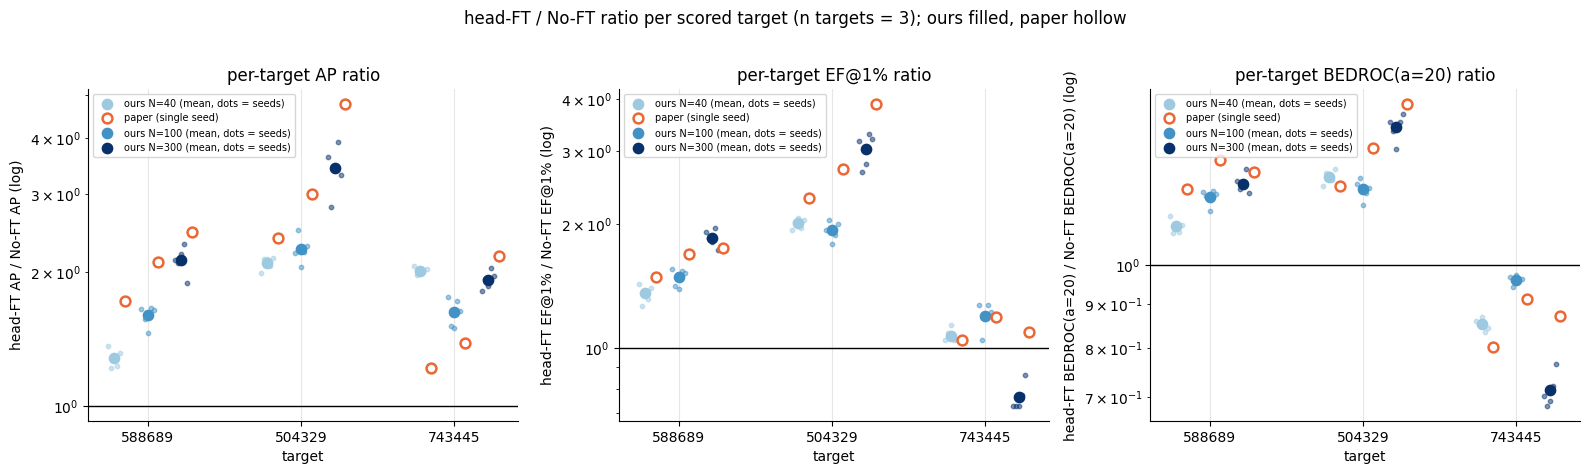

In [6]:
if DONE:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=False); off = {40: -0.22, 100: 0, 300: 0.22}; cols = {40: "#9ecae1", 100: "#4292c6", 300: "#08306b"}
    for ax, m in zip(axes, MCOLS):
        for N in BUD:
            for i, t in enumerate(DONE):
                s = ours_seeds(t, N, m) / ours_base(t, m)
                ax.scatter(np.full(len(s), i + off[N]) + np.linspace(-0.04, 0.04, len(s)), s, s=10, color=cols[N], alpha=0.5)
                ax.scatter(i + off[N], s.mean(), s=55, color=cols[N], label=f"ours N={N} (mean, dots = seeds)" if i == 0 else None, zorder=4)
                ax.scatter(i + off[N] + 0.07, paper_ft(t, N, m) / paper_base(t, m), s=50, facecolor="white", edgecolor=THEIR, lw=1.8, label="paper (single seed)" if (i == 0 and N == 40) else None, zorder=5)
        ax.axhline(1, color="black", lw=1); ax.set_yscale("log"); ax.set_xticks(range(len(DONE))); ax.set_xticklabels([SHORT[t] for t in DONE])
        ax.set_xlabel("target"); ax.set_ylabel(f"head-FT {MNAME[m]} / No-FT {MNAME[m]} (log)"); ax.set_title(f"per-target {MNAME[m]} ratio"); ax.legend(fontsize=7)
    plt.suptitle(f"head-FT / No-FT ratio per scored target (n targets = {K}); ours filled, paper hollow", y=1.02); plt.tight_layout(); plt.show()
else: print("pending: no scored target, nothing to draw")

## 4. AP per target on a log absolute axis (paper vs ours)
No-FT and head-FT N=40/100/300. Orange hollow = paper; blue = ours (marker = seed mean, bar = seed SD, small dots = the 5 seeds). Dashed line = the target's active rate, which is the AP of a random ranking. Unscored targets show the paper only.

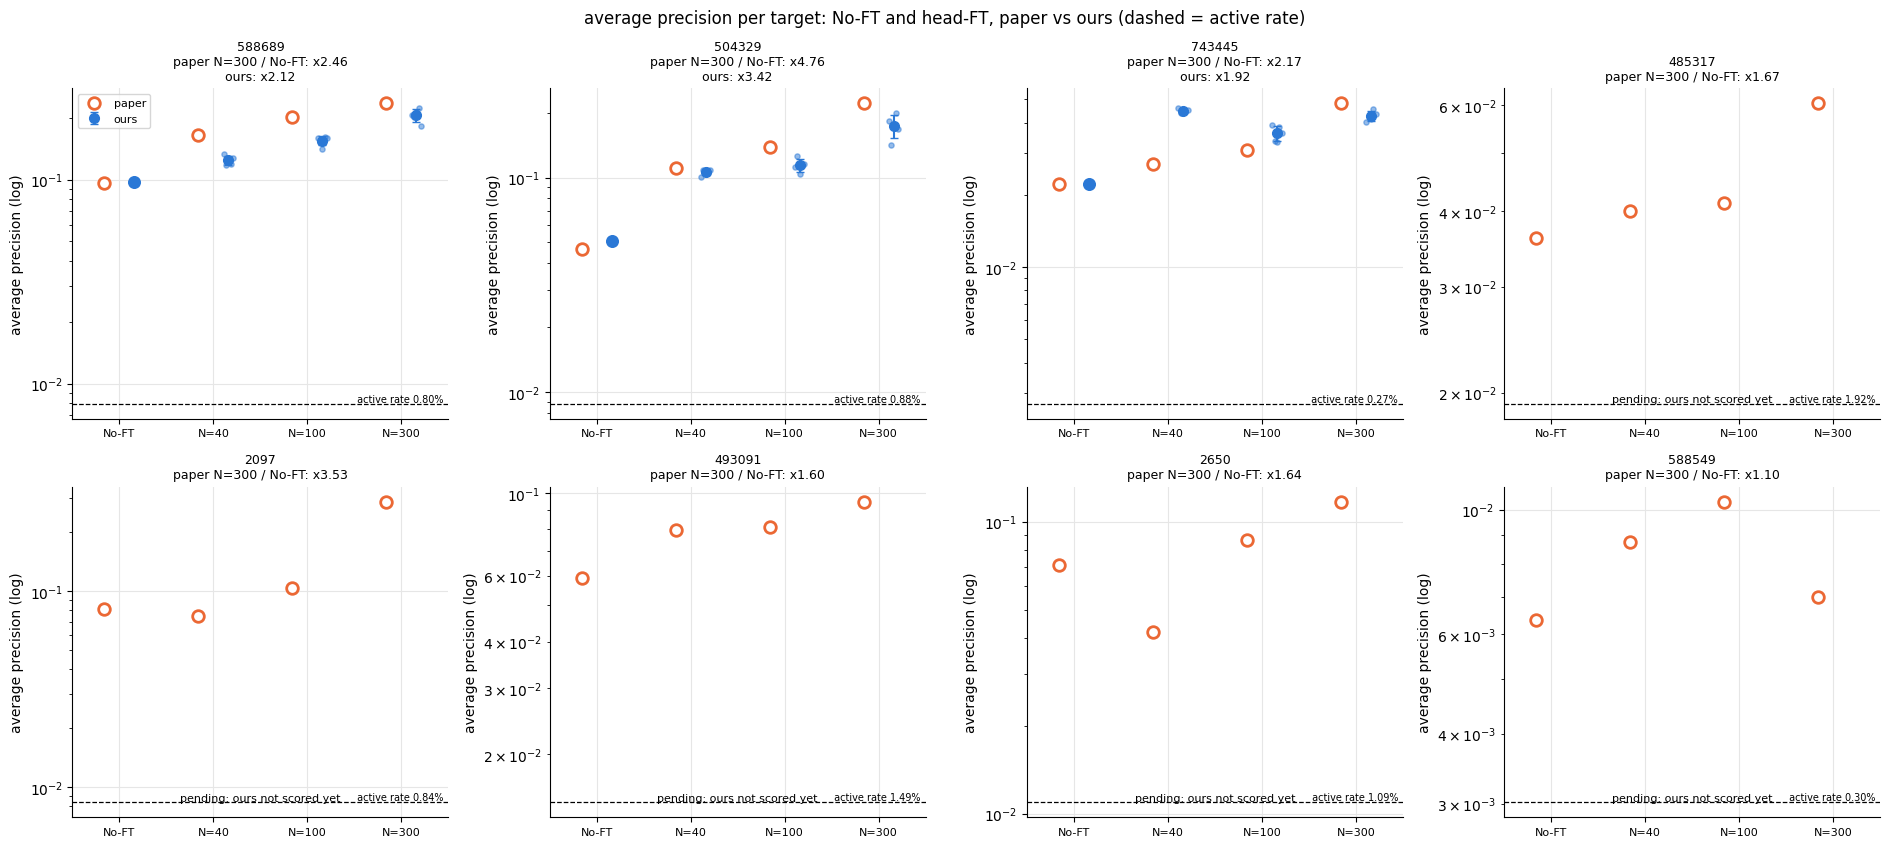

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8.6))
for ax, t in zip(axes.ravel(), TARGETS):
    xs = np.arange(4); labs = ["No-FT"] + [f"N={b}" for b in BUD]
    pv = [paper_base(t, "ap")] + [paper_ft(t, b, "ap") for b in BUD]
    ax.scatter(xs - 0.16, pv, s=70, facecolor="white", edgecolor=THEIR, lw=2, zorder=4, label="paper")
    txt = f"paper N=300 / No-FT: x{pv[3]/pv[0]:.2f}"
    if t in MT:
        b0 = ours_base(t, "ap"); means = [b0]; sds = [0.0]; ax.scatter([0.16], [b0], s=70, color=OUR, zorder=4)
        for i, b in enumerate(BUD):
            s = ours_seeds(t, b, "ap"); means.append(s.mean()); sds.append(s.std(ddof=1))
            ax.scatter(np.full(len(s), i + 1.16) + np.linspace(-0.05, 0.05, len(s)), s, s=14, color=OUR, alpha=0.5, zorder=3)
        ax.errorbar(xs + 0.16, means, yerr=sds, fmt="o", color=OUR, ms=7, capsize=3, zorder=5, label="ours")
        txt += f"\nours: x{means[3]/means[0]:.2f}"
    else: ax.text(0.5, 0.05, "pending: ours not scored yet", transform=ax.transAxes, ha="center", fontsize=8)
    ax.axhline(RATE[t], ls="--", color="black", lw=0.9); ax.text(3.45, RATE[t], f" active rate {100*RATE[t]:.2f}%", va="bottom", ha="right", fontsize=7)
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(labs, fontsize=8); ax.set_xlim(-0.5, 3.5)
    ax.set_title(f"{SHORT[t]}\n{txt}", fontsize=9); ax.set_ylabel("average precision (log)")
    if t == TARGETS[0]: ax.legend(fontsize=8, loc="upper left")
fig.suptitle("average precision per target: No-FT and head-FT, paper vs ours (dashed = active rate)", fontsize=12); plt.tight_layout(); plt.show()

## 5. AP as a multiple of chance, and lift per target
AP divided by the active rate (1 = random). The table lists all 8 targets with paper and our values side by side.

,active_rate_pct,paper_NoFT_AP,paper_N300_AP,paper_NoFT_x_chance,paper_N300_x_chance,paper_lift,ours_NoFT_AP,ours_N300_AP,ours_NoFT_x_chance,ours_N300_x_chance,ours_lift
target,,,,,,,,,,,
588689,0.797,0.096,0.237,12.050,29.686,2.464,0.097,0.207,12.217,25.946,2.124
504329,0.882,0.047,0.222,5.283,25.168,4.764,0.051,0.174,5.759,19.721,3.424
743445,0.270,0.022,0.048,8.222,17.862,2.172,0.022,0.043,8.253,15.839,1.919
485317,1.918,0.036,0.060,1.884,3.149,1.671,pending,pending,pending,pending,pending
2097,0.836,0.081,0.286,9.688,34.165,3.526,pending,pending,pending,pending,pending
493091,1.487,0.059,0.095,3.978,6.363,1.600,pending,pending,pending,pending,pending
2650,1.093,0.071,0.117,6.515,10.693,1.641,pending,pending,pending,pending,pending
588549,0.302,0.006,0.007,2.107,2.319,1.101,pending,pending,pending,pending,pending


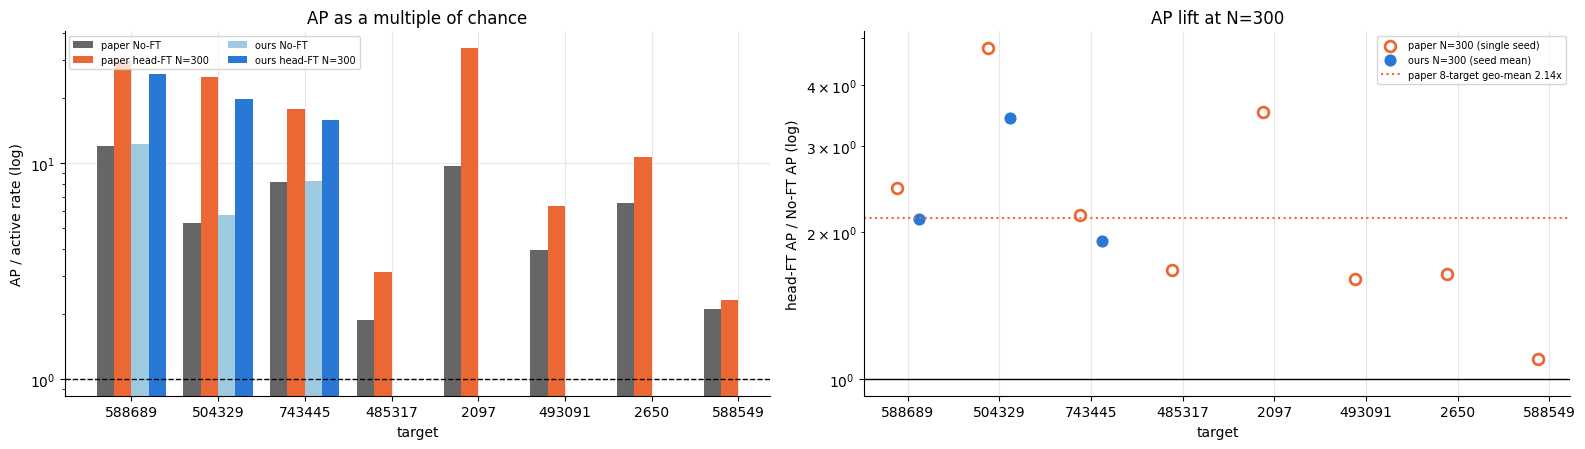

In [8]:
rows = []
for t in TARGETS:
    r = dict(target=SHORT[t], active_rate_pct=100 * RATE[t], paper_NoFT_AP=paper_base(t, "ap"), paper_N300_AP=paper_ft(t, 300, "ap"),
             paper_NoFT_x_chance=paper_base(t, "ap") / RATE[t], paper_N300_x_chance=paper_ft(t, 300, "ap") / RATE[t], paper_lift=paper_ft(t, 300, "ap") / paper_base(t, "ap"))
    if t in MT:
        s = ours_seeds(t, 300, "ap"); r.update(ours_NoFT_AP=ours_base(t, "ap"), ours_N300_AP=s.mean(), ours_NoFT_x_chance=ours_base(t, "ap") / RATE[t], ours_N300_x_chance=s.mean() / RATE[t], ours_lift=s.mean() / ours_base(t, "ap"))
    rows.append(r)
LIFT = pd.DataFrame(rows).set_index("target"); display(LIFT.style.format(precision=3, na_rep="pending"))
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6)); x = np.arange(8); w = 0.2
ax = axes[0]
ax.bar(x - 1.5*w, LIFT.paper_NoFT_x_chance, w, color=NEU, label="paper No-FT"); ax.bar(x - 0.5*w, LIFT.paper_N300_x_chance, w, color=THEIR, label="paper head-FT N=300")
if "ours_NoFT_x_chance" in LIFT:
    ax.bar(x + 0.5*w, LIFT.ours_NoFT_x_chance, w, color="#9ecae1", label="ours No-FT"); ax.bar(x + 1.5*w, LIFT.ours_N300_x_chance, w, color=OUR, label="ours head-FT N=300")
ax.axhline(1, color="black", ls="--", lw=1); ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(LIFT.index); ax.set_xlabel("target"); ax.set_ylabel("AP / active rate (log)"); ax.set_title("AP as a multiple of chance"); ax.legend(fontsize=7, ncol=2)
ax = axes[1]
ax.scatter(x - 0.12, LIFT.paper_lift, s=60, facecolor="white", edgecolor=THEIR, lw=2, label="paper N=300 (single seed)")
if "ours_lift" in LIFT: ax.scatter(x + 0.12, LIFT.ours_lift, s=60, color=OUR, label="ours N=300 (seed mean)")
ax.axhline(1, color="black", lw=1); ax.axhline(PG[("AP", 300)], color=THEIR, ls=":", label=f"paper 8-target geo-mean {PG[('AP',300)]:.2f}x")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(LIFT.index); ax.set_xlabel("target"); ax.set_ylabel("head-FT AP / No-FT AP (log)"); ax.set_title("AP lift at N=300"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6. Multi-seed spread, and how far the paper's single seed is from our seed mean
Per target and budget: mean, SD, min and max of AP over our 5 seeds. `paper_minus_ours_mean` is the paper's (single-seed) AP minus our seed mean, and `in_SDs` expresses it in units of our seed SD (a rough guide only: the paper's run also differs in inputs, so this is not a pure seed-noise comparison).

In [9]:
rows = []
for t in DONE:
    b = ours_base(t, "ap"); rows.append(dict(target=SHORT[t], N=0, n_seeds=1, mean=b, sd=np.nan, min=b, max=b, paper=paper_base(t, "ap"), paper_minus_ours_mean=paper_base(t, "ap") - b, in_SDs=np.nan))
    for N in BUD:
        s = ours_seeds(t, N, "ap"); p = paper_ft(t, N, "ap")
        rows.append(dict(target=SHORT[t], N=N, n_seeds=len(s), mean=s.mean(), sd=s.std(ddof=1), min=s.min(), max=s.max(), paper=p, paper_minus_ours_mean=p - s.mean(), in_SDs=(p - s.mean()) / s.std(ddof=1)))
SP = pd.DataFrame(rows)
if len(SP):
    display(SP.style.format(precision=4, na_rep="-").hide(axis="index"))
    h = SP[SP.N > 0]
    print(f"head-FT arms: paper value lies inside our [min, max] over seeds in {int(((h.paper >= h['min']) & (h.paper <= h['max'])).sum())}/{len(h)} (target, budget) cells; "
          f"median relative seed SD (SD/mean) = {100*(h.sd/h['mean']).median():.1f}% ; median |paper - ours| / ours = {100*(h.paper_minus_ours_mean.abs()/h['mean']).median():.1f}%.")
    sdall = []
    for t in DONE:
        for N in BUD: sdall.append(ours_seeds(t, N, "ap").std(ddof=1) / ours_seeds(t, N, "ap").mean())
    print(f"seed-to-seed relative SD of AP ranges {100*min(sdall):.1f}% to {100*max(sdall):.1f}% over scored (target, budget) cells.")
else: print("pending: no scored target")

target,N,n_seeds,mean,sd,min,max,paper,paper_minus_ours_mean,in_SDs
588689,0,1,0.0974,-,0.0974,0.0974,0.0960,-0.0013,-
588689,40,5,0.1247,0.0061,0.1181,0.1330,0.1649,0.0402,6.5468
588689,100,5,0.1555,0.0082,0.1421,0.1619,0.2020,0.0465,5.6561
588689,300,5,0.2068,0.0149,0.1843,0.2249,0.2366,0.0298,1.9954
504329,0,1,0.0508,-,0.0508,0.0508,0.0466,-0.0042,-
504329,40,5,0.1063,0.0035,0.1008,0.1089,0.1112,0.0049,1.4185
504329,100,5,0.1142,0.0078,0.1044,0.1259,0.1394,0.0251,3.2270
504329,300,5,0.1739,0.0212,0.1419,0.1993,0.2219,0.0480,2.2600
743445,0,1,0.0223,-,0.0223,0.0223,0.0222,-0.0001,-
743445,40,5,0.0448,0.0008,0.0438,0.0459,0.0270,-0.0178,-23.1047


head-FT arms: paper value lies inside our [min, max] over seeds in 0/9 (target, budget) cells; median relative seed SD (SD/mean) = 5.3% ; median |paper - ours| / ours = 22.0%.
seed-to-seed relative SD of AP ranges 1.7% to 12.2% over scored (target, budget) cells.


## 7. Is the paper's headline reproduced?
All numbers below are computed above. The comparison is like for like only on the same target subset; the paper's 8-target value is shown for reference.

In [10]:
if K == 0:
    print("No scored target yet: headline cannot be assessed.")
else:
    tl = ", ".join(SHORT[t] for t in DONE)
    for m in ["ap", "ef1"]:
        r = T2[(T2.metric == MNAME[m]) & (T2.N == 300)].iloc[0]
        line = (f"{MNAME[m]} at N=300 over k = {K} scored target(s) [{tl}]: ours geo-mean ratio {r.ours_geo_ratio:.2f}x"
                + (f" (95% t-CI {r['ours 95% t-CI']})" if K > 1 else "") + f"; paper on the same targets {r.paper_geo_same_targets:.2f}x; paper on all 8 targets {r.paper_geo_8_targets:.2f}x.")
        print(line)
        if K > 1:
            lo, hi = [float(v) for v in r["ours 95% t-CI"].strip("[]").split(",")]
            print(f"   paper same-target value {'lies inside' if lo <= r.paper_geo_same_targets <= hi else 'lies outside'} our CI; paper 8-target value {'lies inside' if lo <= r.paper_geo_8_targets <= hi else 'lies outside'} our CI. "
                  f"improved {r.improved}, sign p = {r.sign_p:.3f}, Wilcoxon p = {r.wilcoxon_p:.3f}.")
    if K < 8: print(f"\nOnly {K}/8 targets are scored, so this is a partial replication; the cross-target claim needs all 8 and the conclusion will change as targets finish.")
    if K < 6: print(f"With k = {K} no cross-target test can reach p < 0.05 (minimum sign-test p = {2*0.5**K:.3f}); the ratios are descriptive.")
    else: print(f"Bonferroni over the {len(T2)} (metric x budget) rows: threshold {0.05/len(T2):.4f}.")
    # per-target direction
    for t in DONE:
        print(f"{SHORT[t]}: ours AP ratio N=300 {np.mean(ours_seeds(t,300,'ap'))/ours_base(t,'ap'):.2f}x vs paper {paper_ft(t,300,'ap')/paper_base(t,'ap'):.2f}x; "
              f"No-FT AP ours {ours_base(t,'ap'):.3f} vs paper {paper_base(t,'ap'):.3f}")

AP at N=300 over k = 3 scored target(s) [588689, 504329, 743445]: ours geo-mean ratio 2.41x (95% t-CI [1.12, 5.19]); paper on the same targets 2.94x; paper on all 8 targets 2.14x.
   paper same-target value lies inside our CI; paper 8-target value lies inside our CI. improved 3/3, sign p = 0.250, Wilcoxon p = 0.250.
EF@1% at N=300 over k = 3 scored target(s) [588689, 504329, 743445]: ours geo-mean ratio 1.62x (95% t-CI [0.29, 9.19]); paper on the same targets 1.95x; paper on all 8 targets 1.77x.
   paper same-target value lies inside our CI; paper 8-target value lies inside our CI. improved 2/3, sign p = 1.000, Wilcoxon p = 0.500.

Only 3/8 targets are scored, so this is a partial replication; the cross-target claim needs all 8 and the conclusion will change as targets finish.
With k = 3 no cross-target test can reach p < 0.05 (minimum sign-test p = 0.250); the ratios are descriptive.
588689: ours AP ratio N=300 2.12x vs paper 2.46x; No-FT AP ours 0.097 vs paper 0.096
504329: ours AP r

## 8. What differs from the paper
- **Same evaluation set per target**: the eval compounds are the paper's (the common eval set, n_eval and n_active match trainer_control.csv where checked above), so No-FT values should agree closely; small differences come from our independently reconstructed protein sequences / MSAs and poses, which are not bit-identical to the authors'.
- **Seeds**: the paper reports one training seed (seed 0); we train 5 seeds per budget and report the seed mean and spread, so our per-target head-FT values are less noisy than the paper's single-seed numbers.
- **Training set**: the N highest-ranked actives per target (top-N), as in the paper's recipe; head-only fine-tuning of the affinity module.
- **Statistics**: cross-target tests use targets as the unit and seed-averaged values; with few scored targets they are descriptive (see the k printed at the top).